In [1]:
from google.colab import drive
drive.mount('/content/drive')
!cp /content/drive/MyDrive/Yolov7/yolov7.zip -d /content/yolov7.zip

Mounted at /content/drive


In [2]:
!unzip -q /content/yolov7.zip -d /content/project

In [3]:
!mv /content/project/content/drive/MyDrive/yolov7/ /content/project/
!rm -rf /content/project/content/

In [4]:
!pip install sahi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.7/111.7 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 MB 37.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 21.6 MB/s eta 0:00:00
  Attempting uninstall: opencv-python
    Found existing installation: opencv-python 4.13.0.92
    Uninstalling opencv-python-4.13.0.92:
      Successfully uninstalled opencv-python-4.13.0.92


In [5]:
import os
import json
import random
import argparse
import shutil
from pathlib import Path
from PIL import Image, UnidentifiedImageError # Added these imports

# ---------------------------------------------------------------------------
# SeaDronesSee class mapping
# COCO JSON uses category_id starting at 0 for this dataset.
# Verify with: check first annotation in instances_train.json
# If you see category_ids like {1,2,3,4,5,6} (not starting at 0),
# set CATEGORY_ID_OFFSET = -1 below.
# ---------------------------------------------------------------------------
CATEGORY_ID_OFFSET = 0   # change to -1 if class IDs in JSON start at 1

# ---------------------------------------------------------------------------
# Default SAHI parameters (change via CLI args or edit here)
# ---------------------------------------------------------------------------
DEFAULT_SLICE_SIZE = 640
DEFAULT_OVERLAP    = 0.1      # 10% overlap between adjacent patches
DEFAULT_MIN_AREA   = 0.1      # drop boxes that are more than 90% cut off
DEFAULT_SAMPLE     = 1.0      # keep 100% of patches (use 0.25 for quick tests)


def convert_sahi_coco_to_yolo(sahi_json_path: Path, output_labels_dir: Path):
    """
    Convert the COCO JSON that SAHI produces into YOLO .txt label files.
    One .txt file is created per image slice, named identically to the image.
    """
    output_labels_dir.mkdir(parents=True, exist_ok=True)

    with open(sahi_json_path, "r") as f:
        data = json.load(f)

    # Build image_id → image_info lookup for fast access
    images = {img["id"]: img for img in data["images"]}

    print(f"    Converting {len(data['annotations'])} annotations "
          f"across {len(data['images'])} slices to YOLO format...")

    for ann in data["annotations"]:
        img_info = images[ann["image_id"]]

        # COCO bbox: [x_min, y_min, width, height] — all in pixels
        x_min, y_min, w_box, h_box = ann["bbox"]
        w_img = img_info["width"]
        h_img = img_info["height"]

        # Convert to YOLO normalised centre format
        x_centre = (x_min + w_box / 2.0) / w_img
        y_centre  = (y_min + h_box / 2.0) / h_img
        w_norm    = w_box / w_img
        h_norm    = h_box / h_img

        # Guard: clamp to [0, 1] in case of floating-point edge drift
        x_centre = max(0.0, min(1.0, x_centre))
        y_centre  = max(0.0, min(1.0, y_centre))
        w_norm    = max(0.0, min(1.0, w_norm))
        h_norm    = max(0.0, min(1.0, h_norm))

        class_id = ann["category_id"] + CATEGORY_ID_OFFSET

        # Label file named exactly like the image slice (minus extension)
        stem     = Path(img_info["file_name"]).stem
        txt_path = output_labels_dir / f"{stem}.txt"

        with open(txt_path, "a") as f_out:
            f_out.write(
                f"{class_id} {x_centre:.6f} {y_centre:.6f} "
                f"{w_norm:.6f} {h_norm:.6f}\n"
            )


In [14]:
def remove_corrupted_images(images_dir: Path):
    """
    Checks all image files in a directory for corruption and removes them.
    Returns the count of removed images.
    """
    removed_count = 0
    print(f"  Checking for corrupted images in: {images_dir}")
    for img_path in images_dir.iterdir():
        if img_path.is_file() and img_path.suffix.lower() in ['.jpg', '.jpeg', '.png', '.bmp', '.gif']:
            try:
                with Image.open(img_path) as img:
                    img.verify() # Verify that it is an image
            except (UnidentifiedImageError, OSError) as e:
                print(f"    ☢☢  Corrupted image found and removed: {img_path} - Error: {e}")
                img_path.unlink() # Delete the corrupted image
                removed_count += 1
    if removed_count > 0:
        print(f"  Removed {removed_count} corrupted images from {images_dir}.")
    else:
        print(f"  No corrupted images found in {images_dir}.")
    return removed_count

def clean_coco_json(coco_json_path: Path, images_dir: Path) -> Path:
    """
    Reads the COCO JSON, removes images (and their annotations) that
    do not exist on disk, and saves a cleaned JSON.
    """
    with open(coco_json_path, 'r') as f:
        data = json.load(f)

    valid_images = []
    valid_image_ids = set()

    for img in data.get('images', []):
        img_path = images_dir / img['file_name']
        if img_path.exists():
            valid_images.append(img)
            valid_image_ids.add(img['id'])

    valid_annotations = [
        ann for ann in data.get('annotations', []) if ann['image_id'] in valid_image_ids
    ]

    cleaned_data = {
        "info": data.get("info", {}),
        "licenses": data.get("licenses", []),
        "categories": data.get("categories", []),
        "images": valid_images,
        "annotations": valid_annotations
    }

    cleaned_json_path = coco_json_path.parent / f"{coco_json_path.stem}_cleaned.json"
    with open(cleaned_json_path, 'w') as f:
        json.dump(cleaned_data, f)

    print(f"  [JSON Cleanup] Kept {len(valid_images)}/{len(data.get('images', []))} images and {len(valid_annotations)}/{len(data.get('annotations', []))} annotations.")
    return cleaned_json_path

def apply_sampling(images_dir: Path, labels_dir: Path, sample_ratio: float, seed: int = 42):
    """
    Randomly keep only `sample_ratio` fraction of the patches.
    Deletes both the image and its matching label for dropped patches.
    """
    if sample_ratio >= 1.0:
        return  # nothing to do

    all_images = list(images_dir.glob("*.jpg")) + list(images_dir.glob("*.png"))
    random.seed(seed)
    n_keep    = max(1, int(len(all_images) * sample_ratio))
    keep_set  = set(random.sample(all_images, n_keep))
    n_dropped = 0

    for img_path in all_images:
        if img_path not in keep_set:
            img_path.unlink(missing_ok=True)
            txt_path = labels_dir / (img_path.stem + ".txt")
            txt_path.unlink(missing_ok=True)
            n_dropped += 1

    print(f"    Sampling: kept {n_keep}/{len(all_images)} patches "
          f"({sample_ratio*100:.0f}%), dropped {n_dropped}")

def remove_empty_patches(images_dir: Path, labels_dir: Path, keep_ratio: float, seed: int = 42):
    """
    Removes empty patches (images without annotations) keeping only `keep_ratio` fraction.
    """
    if keep_ratio >= 1.0:
        return

    all_images = list(images_dir.glob("*.jpg")) + list(images_dir.glob("*.png"))
    empty_images = []
    for img_path in all_images:
        txt_path = labels_dir / (img_path.stem + ".txt")
        # If no label file exists or it's completely empty, it's a negative sample
        if not txt_path.exists() or txt_path.stat().st_size == 0:
            empty_images.append(img_path)

    random.seed(seed)
    n_keep = int(len(empty_images) * keep_ratio)
    # Select images to drop
    images_to_drop = random.sample(empty_images, len(empty_images) - n_keep)

    for img_path in images_to_drop:
        img_path.unlink(missing_ok=True)
        txt_path = labels_dir / (img_path.stem + ".txt")
        txt_path.unlink(missing_ok=True)

    print(f"    Empty Patches: kept {n_keep}/{len(empty_images)} "
          f"({keep_ratio*100:.0f}%), dropped {len(images_to_drop)}")


def prepare_split(
    split_name:       str,
    coco_json:        Path,
    images_dir:       Path,
    output_root:      Path,
    slice_size:       int,
    overlap:          float,
    min_area:         float,
    sample_ratio:     float,
    empty_keep_ratio: float = 0.1,
):
    from sahi.slicing import slice_coco

    out_images = output_root / split_name / "images"
    out_labels = output_root / split_name / "labels"
    # out_images.mkdir(parents=True, exist_ok=True)
    # out_labels.mkdir(parents=True, exist_ok=True)

    print(f"\n{'='*60}")
    print(f"  Processing split: {split_name.upper()}")
    print(f"  Source images : {images_dir}")
    print(f"  COCO JSON     : {coco_json}")
    print(f"  Slice size    : {slice_size}x{slice_size}")
    print(f"  Overlap       : {overlap*100:.0f}%")
    print(f"  Min area ratio: {min_area}")
    print(f"  Sample ratio  : {sample_ratio*100:.0f}%")
    print(f"  Keep empty    : {empty_keep_ratio*100:.0f}%")
    print(f"{'='*60}")

    if not images_dir.exists() or not any(images_dir.iterdir()):
        print(f"  ☢☢  WARNING: {images_dir} is empty or does not exist.")
        print(f"  ☢☢  Download and place your {split_name} images there first, then re-run.")
        return

    if not coco_json.exists():
        print(f"  ❌ ERROR: {coco_json} not found. Cannot process {split_name}.")
        return

    # --- NEW STEP: Check and remove corrupted images ---
    removed_count = remove_corrupted_images(images_dir)
    if removed_count > 0:
        print(f"  Proceeding with remaining {len(list(images_dir.iterdir()))} images after removing corrupted ones.")

    # --- CLEAN COCO JSON ---
    cleaned_coco_json = clean_coco_json(coco_json, images_dir)

    # --- Step 1: SAHI slicing ---
    print(f"\n  [1/3] Slicing images with SAHI...")
    _, sahi_json_path = slice_coco(
        coco_annotation_file_path=str(cleaned_coco_json),
        image_dir=str(images_dir),
        output_coco_annotation_file_name=f"sliced_{split_name}",
        ignore_negative_samples=False,
        output_dir=str(out_images),
        slice_height=slice_size,
        slice_width=slice_size,
        overlap_height_ratio=overlap,
        overlap_width_ratio=overlap,
        min_area_ratio=min_area,
        verbose=False,
    )

    # SAHI saves the JSON inside the images output dir
    sahi_json_path = out_images / f"sliced_{split_name}_coco.json"
    if not sahi_json_path.exists():
        # fallback: SAHI sometimes names it without the split suffix
        candidates = list(out_images.glob("*.json"))
        if candidates:
            sahi_json_path = candidates[0]
        else:
            print(f"  ❌ Could not find SAHI output JSON in {out_images}. Aborting.")
            return

    # --- Step 2: Convert to YOLO .txt ---
    print(f"\n  [2/3] Converting SAHI COCO JSON → YOLO .txt labels...")
    convert_sahi_coco_to_yolo(sahi_json_path, out_labels)

    # --- Step 3: Optional empty patch sampling ---
    print(f"\n  [3/3] Handling empty negative samples ({empty_keep_ratio*100:.0f}%)...")
    remove_empty_patches(out_images, out_labels, empty_keep_ratio)

    # --- Step 4: Optional global sampling ---
    if sample_ratio < 1.0:
        print(f"\n  [4/4] Applying overall sampling ({sample_ratio*100:.0f}%)...")
        apply_sampling(out_images, out_labels, sample_ratio)

    # --- Summary ---
    n_images = len(list(out_images.glob("*.jpg"))) + len(list(out_images.glob("*.png")))
    n_labels = len(list(out_labels.glob("*.txt")))
    print(f"\n  ✅ {split_name.upper()} done.")
    print(f"     Images : {n_images}  →  {out_images}")
    print(f"     Labels : {n_labels}  →  {out_labels}")


In [15]:
def write_yaml(output_root: Path, base_dir: Path):
    """Write a ready-to-use SeaDronesSee_SAHI.yaml for YOLOv7 training."""
    yaml_path = base_dir / "data" / "SeaDronesSee_SAHI.yaml"
    sahi_train = (output_root / "train" / "images").resolve()
    sahi_val   = (output_root / "val"   / "images").resolve()
    test_dir   = (base_dir / "data" / "test" / "images").resolve()

    content = f"""\
# SeaDronesSee — SAHI pre-processed dataset config for YOLOv7
# Generated automatically by prepare_sahi_dataset.py

train: {sahi_train.as_posix()}
val:   {sahi_val.as_posix()}
test:  {test_dir.as_posix()}

nc: 7
names: ['ignored', 'swimmer', 'boat', 'jetski', 'life_saving_appliances', 'buoy']
"""
    with open(yaml_path, "w") as f:
        f.write(content)
    print(f"\n  📄 YAML written to: {yaml_path}")
    return yaml_path


In [16]:
# ---------------------------------------------------------------------------
# Entry point
# ---------------------------------------------------------------------------
parser = argparse.ArgumentParser(description="SAHI pre-processing for SeaDronesSee OD dataset")
parser.add_argument("--slice",   type=int,   default=DEFAULT_SLICE_SIZE,
                    help="Patch size in pixels (default: 640)")
parser.add_argument("--overlap", type=float, default=DEFAULT_OVERLAP,
                    help="Overlap ratio between patches, 0–1 (default: 0.1)")
parser.add_argument("--minarea", type=float, default=DEFAULT_MIN_AREA,
                    help="Min bbox area ratio to keep (default: 0.1)")
parser.add_argument("--sample",  type=float, default=DEFAULT_SAMPLE,
                    help="Fraction of patches to keep, 0–1 (default: 1.0 = all)")
parser.add_argument("--keep-empty", type=float, default=0.1,
                    help="Fraction of empty negative patches to keep, 0–1 (default: 0.0)")
parser.add_argument("--splits",  nargs="+",  default=["train"],
                    choices=["train", "val", "test"],
                    help="Which splits to process (default: train val)")


_StoreAction(option_strings=['--splits'], dest='splits', nargs='+', const=None, default=['train'], type=None, choices=['train', 'val', 'test'], required=False, help='Which splits to process (default: train val)', metavar=None)

In [17]:
args, unknown = parser.parse_known_args()
print(args)
# Resolve paths relative to this script's location (yolov7-main/)
BASE_DIR    = Path("/content/project/yolov7").resolve()
DATA_DIR     = BASE_DIR / "data"

Namespace(slice=640, overlap=0.1, minarea=0.1, sample=1.0, keep_empty=0.1, splits=['train'])


In [18]:
ANN_DIR     = DATA_DIR / "annotations"
OUTPUT_ROOT = DATA_DIR / "sahi"

print("\n" + "="*60)
print("  SeaDronesSee — SAHI Dataset Preparation")
print("="*60)
print(f"  Base dir    : {BASE_DIR}")
print(f"  Output root : {OUTPUT_ROOT}")

for split in args.splits:
    prepare_split(
        split_name       = split,
        coco_json        = ANN_DIR / f"instances_{split}.json",
        images_dir       = DATA_DIR / split / "images",
        output_root      = OUTPUT_ROOT,
        slice_size       = args.slice,
        overlap          = args.overlap,
        min_area         = args.minarea,
        sample_ratio     = args.sample,
        empty_keep_ratio = args.keep_empty,
    )

# Write the YAML config for YOLOv7
yaml_path = write_yaml(OUTPUT_ROOT, BASE_DIR)

print("\n" + "="*60)
print("  ALL DONE.")
print("="*60)
print("\nNext steps:")
print("  1. Run the verifier:  python verify_sahi_output.py")
print("  2. Train YOLOv7:")
print(f"     python train.py --workers 4 --device 0 --batch-size 8 --epochs 50 \\")
print(f"       --img {args.slice} {args.slice} --data {yaml_path} \\")
print(f"       --hyp data/hyp.scratch.custom.yaml \\")
print(f"       --cfg cfg/training/yolov7_SeaDronesSee.yaml \\")
print(f"       --name yolov7-SAHI --weights yolov7_training.pt")



  SeaDronesSee — SAHI Dataset Preparation
  Base dir    : /content/project/yolov7
  Output root : /content/project/yolov7/data/sahi

  Processing split: TRAIN
  Source images : /content/project/yolov7/data/train/images
  COCO JSON     : /content/project/yolov7/data/annotations/instances_train.json
  Slice size    : 640x640
  Overlap       : 10%
  Min area ratio: 0.1
  Sample ratio  : 100%
  Keep empty    : 10%
  Checking for corrupted images in: /content/project/yolov7/data/train/images
  No corrupted images found in /content/project/yolov7/data/train/images.
  [JSON Cleanup] Kept 8929/8930 images and 57749/57760 annotations.

  [1/3] Slicing images with SAHI...


100%|██████████| 8929/8929 [18:22<00:00,  8.10it/s]



  [2/3] Converting SAHI COCO JSON → YOLO .txt labels...
    Converting 95704 annotations across 257392 slices to YOLO format...

  [3/3] Handling empty negative samples (10%)...
    Empty Patches: kept 20802/208023 (10%), dropped 187221

  ✅ TRAIN done.
     Images : 70171  →  /content/project/yolov7/data/sahi/train/images
     Labels : 49369  →  /content/project/yolov7/data/sahi/train/labels

  📄 YAML written to: /content/project/yolov7/data/SeaDronesSee_SAHI.yaml

  ALL DONE.

Next steps:
  1. Run the verifier:  python verify_sahi_output.py
  2. Train YOLOv7:
     python train.py --workers 4 --device 0 --batch-size 8 --epochs 50 \
       --img 640 640 --data /content/project/yolov7/data/SeaDronesSee_SAHI.yaml \
       --hyp data/hyp.scratch.custom.yaml \
       --cfg cfg/training/yolov7_SeaDronesSee.yaml \
       --name yolov7-SAHI --weights yolov7_training.pt


In [19]:
import sys
import json
import argparse
import random
from pathlib import Path

try:
    from PIL import Image
    PIL_AVAILABLE = True
except ImportError:
    PIL_AVAILABLE = False
    print("⚠️  Pillow not installed. Image size checks will be skipped.")
    print("   Install with:  pip install Pillow\n")




In [20]:
# Expected class IDs for SeaDronesSee (0-indexed)
# 0=ignored, 1=swimmer, 2=boat, 3=jetski, 4=life_saving_appliances, 5=buoy
# Class 6 also appears in some annotation files
EXPECTED_CLASS_IDS = set(range(7))   # {0, 1, 2, 3, 4, 5, 6}


def check_split(split_name: str, images_dir: Path, labels_dir: Path,
                expected_size: int, sample_check: int = 50) -> bool:

    print(f"\n{'='*60}")
    print(f"  Checking split: {split_name.upper()}")
    print(f"  Images : {images_dir}")
    print(f"  Labels : {labels_dir}")
    print(f"{'='*60}")

    errors   = []
    warnings = []
    passed   = []

    # ------------------------------------------------------------------
    # Check 0: Directories exist
    # ------------------------------------------------------------------
    if not images_dir.exists():
        errors.append(f"Images directory does not exist: {images_dir}")
        print(f"  ❌ Images directory missing — was SAHI run yet?")
        return False

    if not labels_dir.exists():
        errors.append(f"Labels directory does not exist: {labels_dir}")
        print(f"  ❌ Labels directory missing — conversion step may have failed.")
        return False

    # ------------------------------------------------------------------
    # Check 1: Count images and labels
    # ------------------------------------------------------------------
    images = sorted(list(images_dir.glob("*.jpg")) + list(images_dir.glob("*.png")))
    labels = sorted(list(labels_dir.glob("*.txt")))

    if len(images) == 0:
        errors.append("No image files found. SAHI may not have run or images were not downloaded.")
    if len(labels) == 0:
        errors.append("No label files found. Conversion step may have failed.")

    if not errors:
        passed.append(f"Found {len(images)} image patches and {len(labels)} label files")

    # ------------------------------------------------------------------
    # Check 2: Every image has a matching label
    # ------------------------------------------------------------------
    img_stems = {f.stem for f in images}
    lbl_stems = {f.stem for f in labels}

    missing_labels = img_stems - lbl_stems
    if missing_labels:
        sample = list(missing_labels)[:5]
        errors.append(
            f"{len(missing_labels)} images have NO matching label file "
            f"(first 5: {sample})"
        )
    else:
        passed.append("Every image has a matching label file ✓")

    orphan_labels = lbl_stems - img_stems
    if orphan_labels:
        warnings.append(
            f"{len(orphan_labels)} label files have no matching image "
            f"(harmless if caused by JSON-only annotations)"
        )

    # ------------------------------------------------------------------
    # Check 3: No empty label files
    # ------------------------------------------------------------------
    empty_labels = [f for f in labels if f.stat().st_size == 0]
    if empty_labels:
        errors.append(
            f"{len(empty_labels)} label files are EMPTY — "
            f"ignore_negative_samples may not have worked. "
            f"Examples: {[f.name for f in empty_labels[:3]]}"
        )
    else:
        passed.append("All label files are non-empty ✓")

    # ------------------------------------------------------------------
    # Check 4: Image dimensions (sample for speed)
    # ------------------------------------------------------------------
    if PIL_AVAILABLE and images:
        sample_imgs = random.sample(images, min(sample_check, len(images)))
        wrong_size  = []
        for img_path in sample_imgs:
            with Image.open(img_path) as img:
                w, h = img.size
                # Patches at the edge may be smaller than slice_size
                if w > expected_size or h > expected_size:
                    wrong_size.append(f"{img_path.name}: {w}×{h}")
        if wrong_size:
            errors.append(
                f"{len(wrong_size)} sampled images exceed expected size "
                f"{expected_size}×{expected_size}: {wrong_size[:3]}"
            )
        else:
            passed.append(
                f"All sampled images ≤ {expected_size}×{expected_size} ✓ "
                f"(checked {len(sample_imgs)} images)"
            )

    # ------------------------------------------------------------------
    # Check 5: YOLO bounding box sanity (all labels)
    # ------------------------------------------------------------------
    bbox_errors = []
    all_class_ids = set()

    for lbl_path in labels:
        with open(lbl_path) as f:
            for line_num, line in enumerate(f.readlines(), 1):
                line = line.strip()
                if not line:
                    continue
                parts = line.split()

                # Must have exactly 5 values: class x y w h
                if len(parts) != 5:
                    bbox_errors.append(
                        f"{lbl_path.name}:{line_num} — "
                        f"expected 5 values, got {len(parts)}: '{line}'"
                    )
                    continue

                try:
                    cls_id = int(parts[0])
                    coords = [float(v) for v in parts[1:]]
                except ValueError:
                    bbox_errors.append(
                        f"{lbl_path.name}:{line_num} — non-numeric value: '{line}'"
                    )
                    continue

                all_class_ids.add(cls_id)

                # Coordinates must be in [0, 1]
                if any(v < 0.0 or v > 1.0 for v in coords):
                    bbox_errors.append(
                        f"{lbl_path.name}:{line_num} — coords out of [0,1] "
                        f"range: {coords}"
                    )

                # Width and height must be positive
                if coords[2] <= 0 or coords[3] <= 0:
                    bbox_errors.append(
                        f"{lbl_path.name}:{line_num} — zero or negative box "
                        f"dimensions: w={coords[2]}, h={coords[3]}"
                    )

        if len(bbox_errors) > 20:
            bbox_errors.append("... (truncated, too many errors)")
            break

    if bbox_errors:
        errors.append(
            f"{len(bbox_errors)} invalid bounding box lines:\n    "
            + "\n    ".join(bbox_errors[:10])
        )
    else:
        passed.append("All bounding box coordinates are valid YOLO format ✓")

    # ------------------------------------------------------------------
    # Check 6: Class ID range
    # ------------------------------------------------------------------
    unexpected_ids = all_class_ids - EXPECTED_CLASS_IDS
    if unexpected_ids:
        errors.append(
            f"UNEXPECTED class IDs found: {unexpected_ids}\n"
            f"    Expected: {sorted(EXPECTED_CLASS_IDS)}\n"
            f"    Got     : {sorted(all_class_ids)}\n"
            f"    FIX: Set CATEGORY_ID_OFFSET = -1 in prepare_sahi_dataset.py "
            f"and re-run the conversion step."
        )
    else:
        passed.append(
            f"Class IDs are all valid: {sorted(all_class_ids)} ✓"
        )

    # ------------------------------------------------------------------
    # Check 7: Ratio of labels to images (sanity on negative-sample drop)
    # ------------------------------------------------------------------
    if len(images) > 0:
        ratio = len(labels) / len(images)
        if ratio < 0.05:
            warnings.append(
                f"Only {ratio*100:.1f}% of images have labels. "
                f"This may be correct (lots of ocean) but double-check "
                f"ignore_negative_samples worked as intended."
            )
        elif ratio > 1.05:
            warnings.append(
                f"More label files ({len(labels)}) than images ({len(images)}). "
                f"Orphan labels exist — usually harmless."
            )

    # ------------------------------------------------------------------
    # Print results
    # ------------------------------------------------------------------
    for msg in passed:
        print(f"  ✅ {msg}")
    for msg in warnings:
        print(f"  ⚠️  {msg}")

    if errors:
        print(f"\n  🚨 {len(errors)} ERROR(S) FOUND — do NOT train yet:")
        for i, err in enumerate(errors, 1):
            print(f"  [{i}] ❌ {err}")
        return False
    else:
        print(f"\n  🎉 {split_name.upper()} split is CLEAN. Safe to train.")
        return True


# ---------------------------------------------------------------------------
# Entry point
# ---------------------------------------------------------------------------


In [25]:
parser = argparse.ArgumentParser(description="Verify SAHI output before training")
parser.add_argument("--splits", nargs="+", default=["train", "val"],
                    choices=["train", "val", "test"],
                    help="Which splits to verify (default: train val)")
parser.add_argument("--size", type=int, default=640,
                    help="Expected max patch size in pixels (default: 640)")
args, unknown = parser.parse_known_args()

# BASE_DIR    = Path(__file__).parent.resolve()
OUTPUT_ROOT = BASE_DIR / "data" / "sahi"

all_passed = True
for split in args.splits:
    ok = check_split(
        split_name    = split,
        images_dir    = OUTPUT_ROOT / split / "images",
        labels_dir    = OUTPUT_ROOT / split / "labels",
        expected_size = args.size,
    )
    all_passed = all_passed and ok

print("\n" + "="*60)
if all_passed:
    print("  ✅✅  ALL SPLITS PASSED. You do NOT need to re-run SAHI.")
    print("="*60)
    print("\nReady to train. Use this command:")
    yaml_path = BASE_DIR / "data" / "SeaDronesSee_SAHI.yaml"
    print(f"\n  python train.py --workers 4 --device 0 --batch-size 8 --epochs 50 \\")
    print(f"    --img 640 640 --data {yaml_path} \\")
    print(f"    --hyp data/hyp.scratch.custom.yaml \\")
    print(f"    --cfg cfg/training/yolov7_SeaDronesSee.yaml \\")
    print(f"    --name yolov7-SAHI --weights yolov7_training.pt")
    sys.exit(0)
else:
    print("  ❌  ERRORS FOUND. Fix issues above before training.")
    print("="*60)


  Checking split: TRAIN
  Images : /content/project/yolov7/data/sahi/train/images
  Labels : /content/project/yolov7/data/sahi/train/labels
  ✅ Found 70171 image patches and 49369 label files
  ✅ All label files are non-empty ✓
  ✅ All sampled images ≤ 640×640 ✓ (checked 50 images)
  ✅ All bounding box coordinates are valid YOLO format ✓
  ✅ Class IDs are all valid: [1, 2, 3, 4, 5] ✓

  🚨 1 ERROR(S) FOUND — do NOT train yet:
  [1] ❌ 20802 images have NO matching label file (first 5: ['3152_8892_576_0_1216_640', '2991_7408_1728_0_2368_640', '2263_8578_4608_576_5248_1216', '6931_2185_576_0_1216_640', '7086_2340_1728_1152_2368_1792'])

  Checking split: VAL
  Images : /content/project/yolov7/data/sahi/val/images
  Labels : /content/project/yolov7/data/sahi/val/labels
  ✅ Found 11899 image patches and 8221 label files
  ✅ All label files are non-empty ✓
  ✅ All sampled images ≤ 640×640 ✓ (checked 50 images)
  ✅ All bounding box coordinates are valid YOLO format ✓
  ✅ Class IDs are all val

In [30]:
!zip -r /content/yolov7-2.zip /content/project/yolov7/

Streaming output truncated to the last 5000 lines.
  adding: content/project/yolov7/data/test/images/12710.jpg (deflated 0%)
  adding: content/project/yolov7/data/test/images/14407.jpg (deflated 1%)
  adding: content/project/yolov7/data/test/images/2381.jpg (deflated 3%)
  adding: content/project/yolov7/data/test/images/12093.jpg (deflated 4%)
  adding: content/project/yolov7/data/test/images/3207.jpg (deflated 0%)
  adding: content/project/yolov7/data/test/images/97.jpg (deflated 0%)
  adding: content/project/yolov7/data/test/images/6796.jpg (deflated 1%)
  adding: content/project/yolov7/data/test/images/6780.jpg (deflated 1%)
  adding: content/project/yolov7/data/test/images/15579.jpg (deflated 8%)
  adding: content/project/yolov7/data/test/images/10517.jpg (deflated 6%)
  adding: content/project/yolov7/data/test/images/7842.jpg (deflated 3%)
  adding: content/project/yolov7/data/test/images/10607.jpg (deflated 1%)
  adding: content/project/yolov7/data/test/images/8804.jpg (deflated 

In [32]:
!mv /content/yolov7-2.zip /content/drive/MyDrive/DNN_Dataset/

In [33]:
!pip install h5py

In [34]:
import h5py
import numpy as np
from pathlib import Path
from tqdm import tqdm

def create_hdf5_dataset(data_dir: Path, output_file: Path):
    print(f"Creating HDF5 dataset at {output_file}...")

    with h5py.File(output_file, 'w') as h5f:
        # We process 'train' and 'val' splits from the SAHI output
        sahi_dir = data_dir / 'sahi'
        for split in ['train', 'val']:
            img_dir = sahi_dir / split / 'images'
            lbl_dir = sahi_dir / split / 'labels'

            if not img_dir.exists():
                print(f"  Skipping {split}, {img_dir} not found.")
                continue

            print(f"\nProcessing {split} split...")
            split_group = h5f.create_group(split)

            image_files = list(img_dir.glob('*.jpg')) + list(img_dir.glob('*.png'))

            images_group = split_group.create_group('images')
            labels_group = split_group.create_group('labels')

            for img_path in tqdm(image_files, desc=f"  Packing {split}"):
                # Read image as binary bytes
                with open(img_path, 'rb') as f:
                    img_data = f.read()

                # Store binary image data
                images_group.create_dataset(img_path.name, data=np.void(img_data))

                # Read corresponding label if it exists
                lbl_path = lbl_dir / (img_path.stem + '.txt')
                if lbl_path.exists():
                    with open(lbl_path, 'r') as f:
                        lbl_data = f.read()
                else:
                    lbl_data = ""

                # Store label text
                labels_group.create_dataset(img_path.stem, data=lbl_data.encode('utf-8'))

    print(f"\n✅ HDF5 dataset successfully saved to {output_file}")

# Run the creation process
data_root = Path("/content/project/yolov7/data")
hdf5_path = Path("/content/drive/MyDrive/DNN_Dataset/yolov7_sahi_dataset.h5")

# Create parent directory if it doesn't exist
hdf5_path.parent.mkdir(parents=True, exist_ok=True)

create_hdf5_dataset(data_root, hdf5_path)


Creating HDF5 dataset at /content/drive/MyDrive/DNN_Dataset/yolov7_sahi_dataset.h5...

Processing train split...


  Packing train: 100%|██████████| 70171/70171 [10:45<00:00, 108.63it/s]



Processing val split...


  Packing val: 100%|██████████| 11899/11899 [01:20<00:00, 146.94it/s]



✅ HDF5 dataset successfully saved to /content/drive/MyDrive/DNN_Dataset/yolov7_sahi_dataset.h5


Opening /content/drive/MyDrive/DNN_Dataset/yolov7_sahi_dataset.h5...
Found 11899 images in the 'val' split.

--- Sample 1: 1003_1400_0_0_640_640.png ---
Image Size: (640, 640)
YOLO Labels:
(No objects - empty patch)


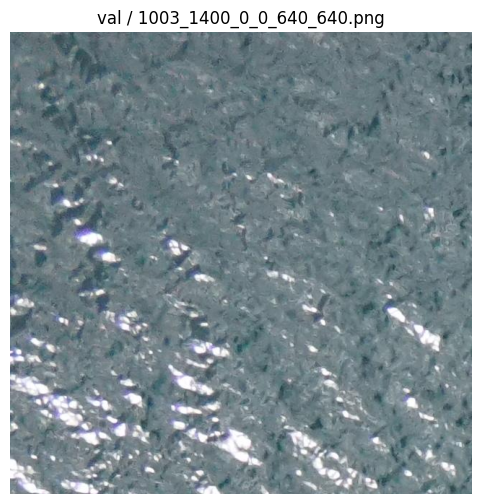

--- Sample 2: 1003_1400_0_2304_640_2944.png ---
Image Size: (640, 640)
YOLO Labels:
(No objects - empty patch)


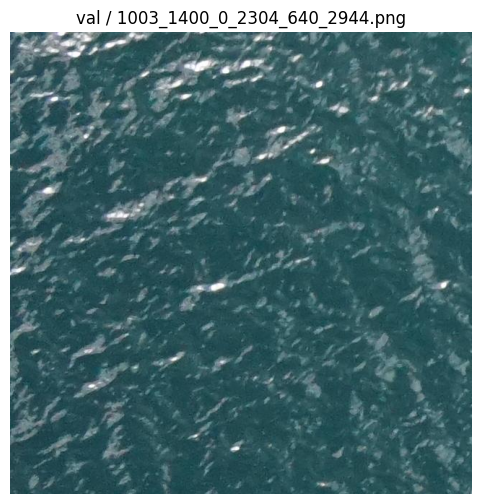

--- Sample 3: 1003_1400_0_576_640_1216.png ---
Image Size: (640, 640)
YOLO Labels:
(No objects - empty patch)


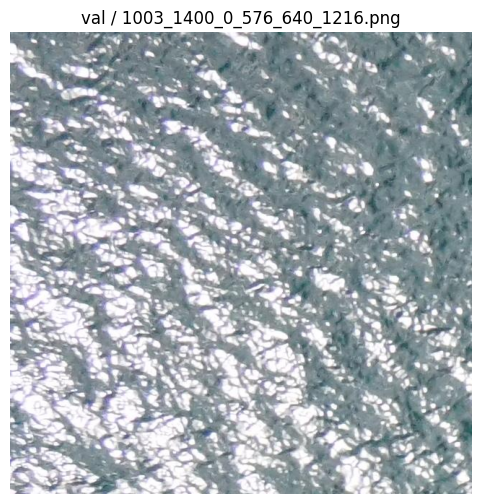

--- Sample 4: 1003_1400_1152_2992_1792_3632.png ---
Image Size: (640, 640)
YOLO Labels:
(No objects - empty patch)


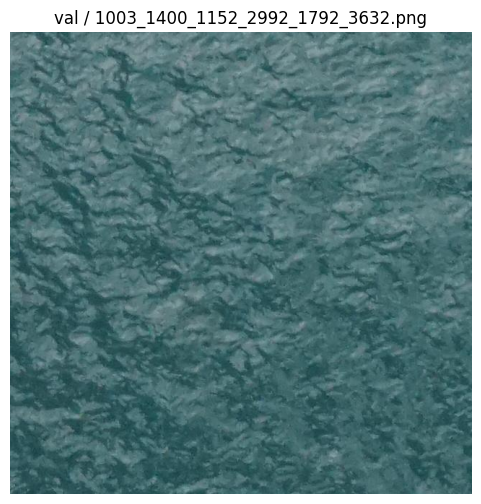

--- Sample 5: 1003_1400_1728_576_2368_1216.png ---
Image Size: (640, 640)
YOLO Labels:
(No objects - empty patch)


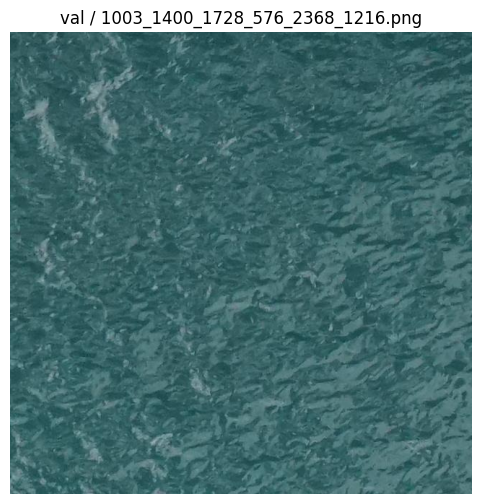

--- Sample 6: 1003_1400_3456_0_4096_640.png ---
Image Size: (640, 640)
YOLO Labels:
1 0.167969 0.335938 0.035937 0.075000
2 0.353125 0.175000 0.112500 0.234375



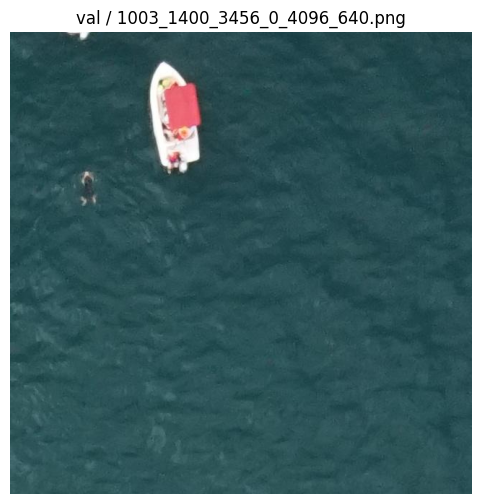

--- Sample 7: 1003_1400_4032_2880_4672_3520.png ---
Image Size: (640, 640)
YOLO Labels:
(No objects - empty patch)


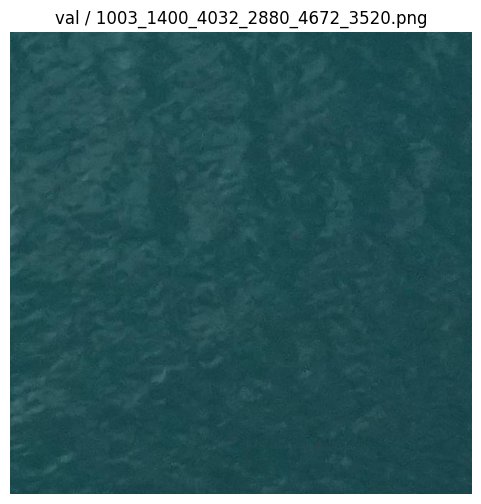

--- Sample 8: 1003_1400_4608_2880_5248_3520.png ---
Image Size: (640, 640)
YOLO Labels:
(No objects - empty patch)


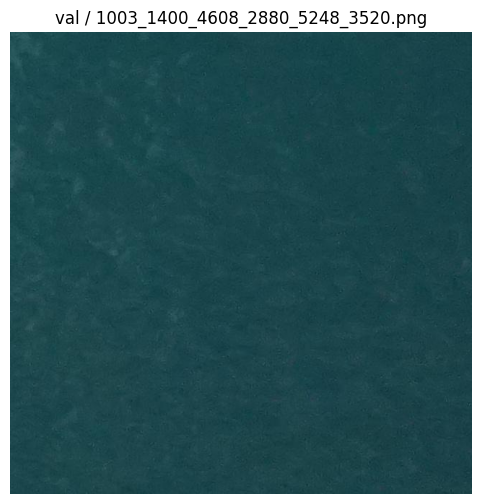

--- Sample 9: 1003_1400_4608_576_5248_1216.png ---
Image Size: (640, 640)
YOLO Labels:
(No objects - empty patch)


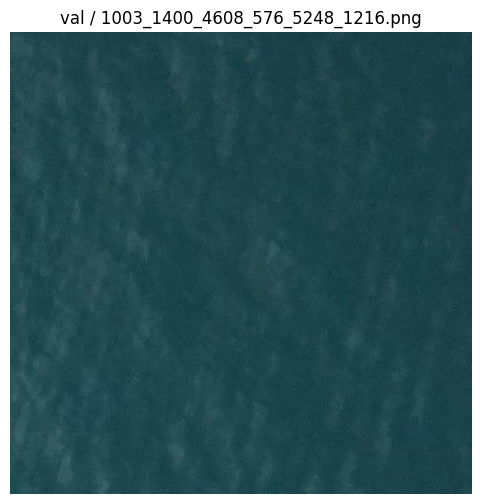

--- Sample 10: 1003_1400_4816_0_5456_640.png ---
Image Size: (640, 640)
YOLO Labels:
(No objects - empty patch)


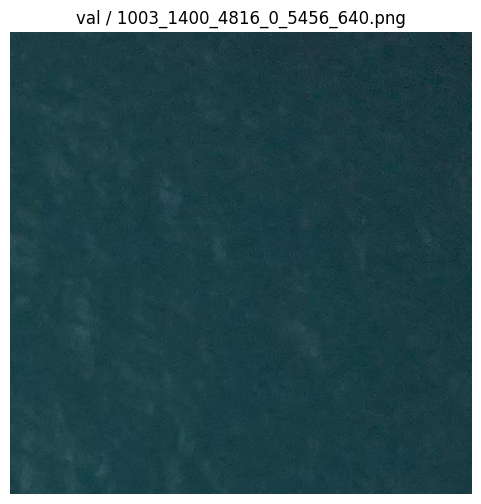

In [36]:
import h5py
import io
from PIL import Image
import matplotlib.pyplot as plt

def read_sample_from_hdf5(hdf5_file, split='train', num_samples=1):
    print(f"Opening {hdf5_file}...")
    with h5py.File(hdf5_file, 'r') as h5f:
        if split not in h5f:
            print(f"Split '{split}' not found in HDF5.")
            return

        images_group = h5f[split]['images']
        labels_group = h5f[split]['labels']

        image_names = list(images_group.keys())
        print(f"Found {len(image_names)} images in the '{split}' split.\n")

        for i in range(min(num_samples, len(image_names))):
            img_name = image_names[i]
            img_stem = img_name.rsplit('.', 1)[0]

            # 1. Read binary image data and convert to PIL Image
            img_binary = images_group[img_name][()]
            img = Image.open(io.BytesIO(img_binary))

            # 2. Read label data and decode from bytes to string
            lbl_text = ""
            if img_stem in labels_group:
                lbl_text = labels_group[img_stem][()].decode('utf-8')

            # Display details
            print(f"--- Sample {i+1}: {img_name} ---")
            print(f"Image Size: {img.size}")
            print(f"YOLO Labels:\n{lbl_text if lbl_text.strip() else '(No objects - empty patch)'}")

            # Plot the image
            plt.figure(figsize=(6, 6))
            plt.imshow(img)
            plt.title(f"{split} / {img_name}")
            plt.axis('off')
            plt.show()

# Let's test reading one image from the validation set
hdf5_path = "/content/drive/MyDrive/DNN_Dataset/yolov7_sahi_dataset.h5"
read_sample_from_hdf5(hdf5_path, split='val', num_samples=10)
